# Categorical Regression



[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/SurveyDataPyMC/blob/main/notebooks/02_categorical_regression.ipynb)

In [1]:
%load_ext autoreload
%autoreload 2
%load_ext jupyter_black

In [2]:
# Get utils.py

from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/SurveyDataPyMC/raw/main/notebooks/utils.py")

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

from utils import value_counts, decorate

In [4]:
# Make the figures smaller to save some screen real estate
plt.rcParams["figure.dpi"] = 75
plt.rcParams["figure.figsize"] = [6, 3.5]
plt.rcParams["axes.titlelocation"] = "left"

## Data

In [5]:
# This dataset is prepared in GssExtract/notebooks/02_make_extract-2022_4.ipynb
# It has been resampled to correct for stratified sampling

DATA_PATH = "https://github.com/AllenDowney/GssExtract/raw/main/data/interim/"
filename = "gss_extract_2022_4.hdf"
download(DATA_PATH + filename)

In [6]:
gss = pd.read_hdf(filename, "gss")
gss.columns

Index(['age', 'attend', 'ballot', 'class', 'clmtcaus', 'clmtusa', 'clmtwrld',
       'cohort', 'commun', 'conarmy', 'conbus', 'conclerg', 'coneduc',
       'confed', 'confinan', 'coninc', 'conjudge', 'conlabor', 'conlegis',
       'conmedic', 'conpress', 'conrinc', 'consci', 'contv', 'degree', 'educ',
       'eqwlth', 'fair', 'fear', 'fund', 'goodlife', 'hapmar', 'happy',
       'health', 'helpful', 'id', 'life', 'partyid', 'polviews', 'pres16',
       'pres20', 'race', 'realinc', 'realrinc', 'reg16', 'region', 'relig',
       'relig16', 'reliten', 'res16', 'rincome', 'satfin', 'satjob', 'sex',
       'sexbirth', 'sexnow', 'srcbelt', 'trust', 'wtssall', 'year'],
      dtype='object')

> Did you vote for Joe Biden or Donald Trump?

```
1 Biden
2 Trump
3 Other
4 Didn't vote
```

In [7]:
value_counts(gss["pres20"])

,counts
values,
1.0,1259
2.0,946
3.0,96
4.0,16
NaN,70073


In [8]:
gss["y"] = gss["pres20"].replace({3: 0, 4: np.nan})
value_counts(gss["y"])

,counts
values,
0.0,96
1.0,1259
2.0,946
NaN,70089


In [9]:
vote_map = {
    0: "Other",
    1: "Biden",
    2: "Trump",
}

In [10]:
from utils import round_into_bins

gss["age_group"] = round_into_bins(gss["age"].copy(), 5, low=13) + 2

In [11]:
gss["y"]

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
72385    2.0
72386    NaN
72387    1.0
72388    NaN
72389    1.0
Name: y, Length: 72390, dtype: float64

In [12]:
table = (
    pd.crosstab(gss["age_group"], gss["y"], normalize="index").rename(columns=vote_map)
    * 100
)

In [13]:
table

y,Other,Biden,Trump
age_group,,,
20,0.680272,61.224490,38.095238
25,9.859155,59.154930,30.985915
30,2.684564,74.496644,22.818792
35,3.816794,59.541985,36.641221
40,5.851064,39.893617,54.255319
45,4.729730,56.418919,38.851351
50,4.149378,48.962656,46.887967
55,5.747126,56.896552,37.356322
60,3.255814,53.953488,42.790698


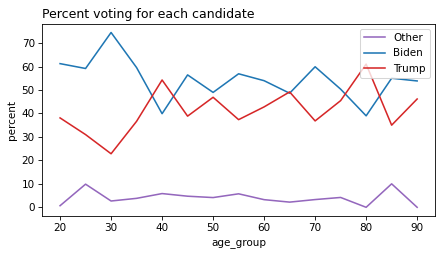

In [14]:
colors = ["C4", "C0", "C3"]
table.plot(color=colors)
decorate(ylabel="percent", title="Percent voting for each candidate")

## Categorical Regression


In [15]:
data = gss.dropna(subset=["y", "age"])
data.shape

(2185, 62)

In [16]:
y = data["y"].values
year = data["year"].values

Shift `year` so it's centered at its mean.

In [18]:
year_shift = data["year"].mean()
year = year - year_shift

Here's the model.

In [22]:
y = data["y"].values
age = data["age"].values

# Center age
age_shift = age.mean()
age_centered = age - age_shift

with pm.Model() as categorical_model:
    # Data
    age_centered_pt = pm.Data("age_centered", age_centered)

    # Priors
    alpha = pm.Normal("alpha", 0, 1, shape=2)  # Biden, Trump (relative to Other)
    beta_age = pm.Normal("beta_age", 0, 1, shape=2)  # Biden, Trump (relative to Other)

    logit_other = np.zeros(len(age))
    logit_biden = alpha[0] + beta_age[0] * age_centered_pt
    logit_trump = alpha[1] + beta_age[1] * age_centered_pt

    logits = pm.Deterministic(
        "logits", pm.math.stack([logit_other, logit_biden, logit_trump], axis=1)
    )

    p = pm.Deterministic("probabilities", pm.math.softmax(logits, axis=1))
    y_obs = pm.Categorical("observed_vote_counts", p=p, observed=y)

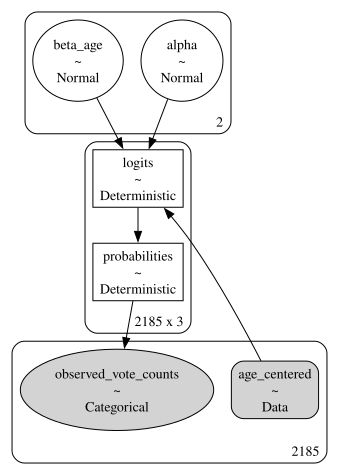

In [23]:
pm.model_to_graphviz(categorical_model)

In [ ]:
with categorical_model:
    idata = pm.sample(500, var_names=['alpha', 'beta_age'])

Output()

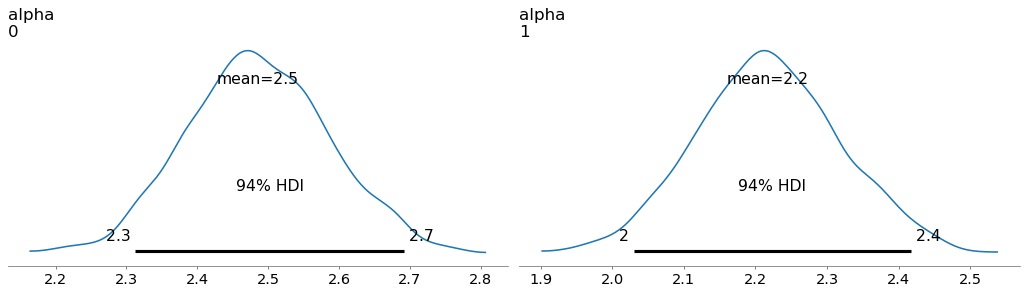

<IPython.core.display.Javascript object>

In [20]:
az.plot_posterior(idata, var_names=["alpha"])
decorate()

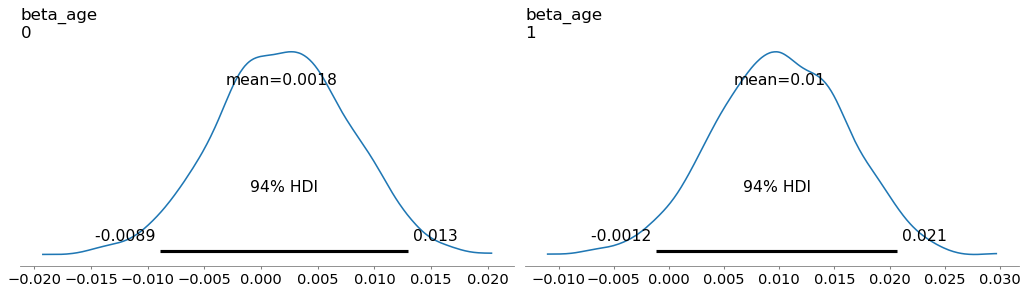

<IPython.core.display.Javascript object>

In [21]:
az.plot_posterior(idata, var_names=["beta_age"])
decorate()

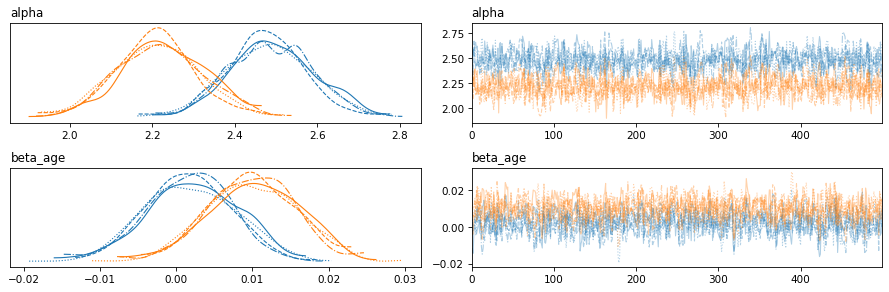

<IPython.core.display.Javascript object>

In [22]:
pm.plot_trace(idata)
decorate()

To check these properties numerically, we can look at two key summary statistics: ESS and r-hat.

*    Effective Sample Size (ESS) tells us how much independent information the chains actually contribute. If successive values within a chain are highly correlated, the chain isn’t exploring the posterior efficiently, and ESS will be smaller than the total number of draws.

*    r-hat quantifies the difference between chains. If all chains converged to the same posterior distribution, r-hat should be close to 1. If the chains are exploring different regions, r-hat will be larger than 1, indicating failure to coverge.

In [23]:
pm.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],2.485,0.103,2.313,2.691,0.003,0.002,1005.0,864.0,1.01
alpha[1],2.217,0.103,2.030,2.417,0.003,0.002,1051.0,1050.0,1.00
beta_age[0],0.002,0.006,-0.009,0.013,0.000,0.000,903.0,985.0,1.00
beta_age[1],0.010,0.006,-0.001,0.021,0.000,0.000,929.0,1122.0,1.00


<IPython.core.display.Javascript object>

### Interpreting the results

In [24]:
def get_sample(idata, var_name):
    """Extract a posterior sample from idata

    idata: InferenceData object
    var_name: string

    returns: NumPy array
    """
    return idata.posterior[var_name].stack(sample=["chain", "draw"])

<IPython.core.display.Javascript object>

In [25]:
alpha = get_sample(idata, "alpha").values
beta_age = get_sample(idata, "beta_age").values
n_dims, n_samples = alpha.shape
n_dims, n_samples

(2, 2000)

<IPython.core.display.Javascript object>

In [43]:
# Center the age range
age_range = np.arange(18, 95)
age_centered = age_range - age_shift
n_ages = len(age_range)

<IPython.core.display.Javascript object>

In [44]:
from scipy.special import softmax

predicted_probs = np.zeros((n_samples, n_ages, 3))

for i in range(n_samples):
    logit_other = np.zeros(n_ages)  # Fixed at zero for reference category
    logit_biden = alpha[0, i] + beta_age[0, i] * age_centered
    logit_trump = alpha[1, i] + beta_age[1, i] * age_centered

    logits = np.stack([logit_other, logit_biden, logit_trump], axis=1)

    # Softmax to get probabilities for all candidates at each age
    predicted_probs[i] = softmax(logits, axis=1)

<IPython.core.display.Javascript object>

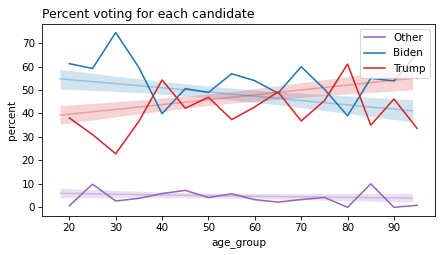

<IPython.core.display.Javascript object>

In [45]:
table.plot(color=colors)

for i, name in vote_map.items():
    mean_prob = predicted_probs[:, :, i].mean(axis=0)
    hdi_low, hdi_high = np.percentile(predicted_probs[:, :, i], [5, 95], axis=0)

    plt.plot(age_range, mean_prob * 100, color=colors[i], alpha=0.3)
    plt.fill_between(
        age_range, hdi_low * 100, hdi_high * 100, color=colors[i], alpha=0.2, lw=0
    )

decorate(ylabel="percent", title="Percent voting for each candidate")

## Adding a categorical predictor

In [26]:
value_counts(gss["sex"])

,counts
values,
1.0,33238
2.0,39001
NaN,151


In [27]:
data = gss.dropna(subset=["y", "age", "sex"])
data.shape

(2184, 62)

In [28]:
y = data["y"].values
age = data["age"].values
sex = data["sex"].values  # 1 = male, 2 = female

# Center age
age_shift = age.mean()
age_centered = age - age_shift

# Recode sex to 0 = male, 1 = female
sex = (sex == 2).astype(int)

In [29]:
with pm.Model() as categorical_model2:
    # Data
    age_centered_pt = pm.Data("age_centered", age_centered)
    sex_pt = pm.Data("sex", sex)

    # Priors
    # Biden, Trump (relative to Other)
    alpha = pm.Normal("alpha", 0, 1, shape=2)

    # Slopes for age (Biden, Trump)
    beta_age = pm.Normal("beta_age", 0, 1, shape=2)

    # Slopes for sex (Biden, Trump)
    beta_sex = pm.Normal("beta_sex", 0, 1, shape=2)

    # Compute logits for each party across all respondents
    logit_other = np.zeros(len(age))
    logit_biden = alpha[0] + beta_age[0] * age_centered_pt + beta_sex[0] * sex_pt
    logit_trump = alpha[1] + beta_age[1] * age_centered_pt + beta_sex[1] * sex_pt

    logits = pm.Deterministic(
        "logits", pm.math.stack([logit_other, logit_biden, logit_trump], axis=1)
    )

    p = pm.Deterministic("probabilities", pm.math.softmax(logits, axis=1))

    y_obs = pm.Categorical("observed_vote_counts", p=p, observed=y)

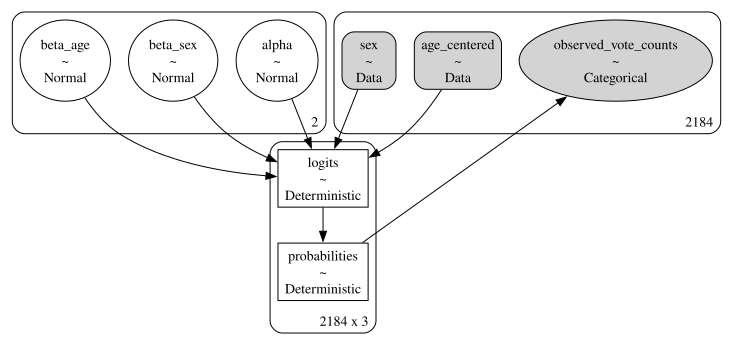

In [30]:
pm.model_to_graphviz(categorical_model2)

In [ ]:
with categorical_model2:
    idata2 = pm.sample(500, var_names=["alpha", "beta_age", "beta_sex"])

Output()

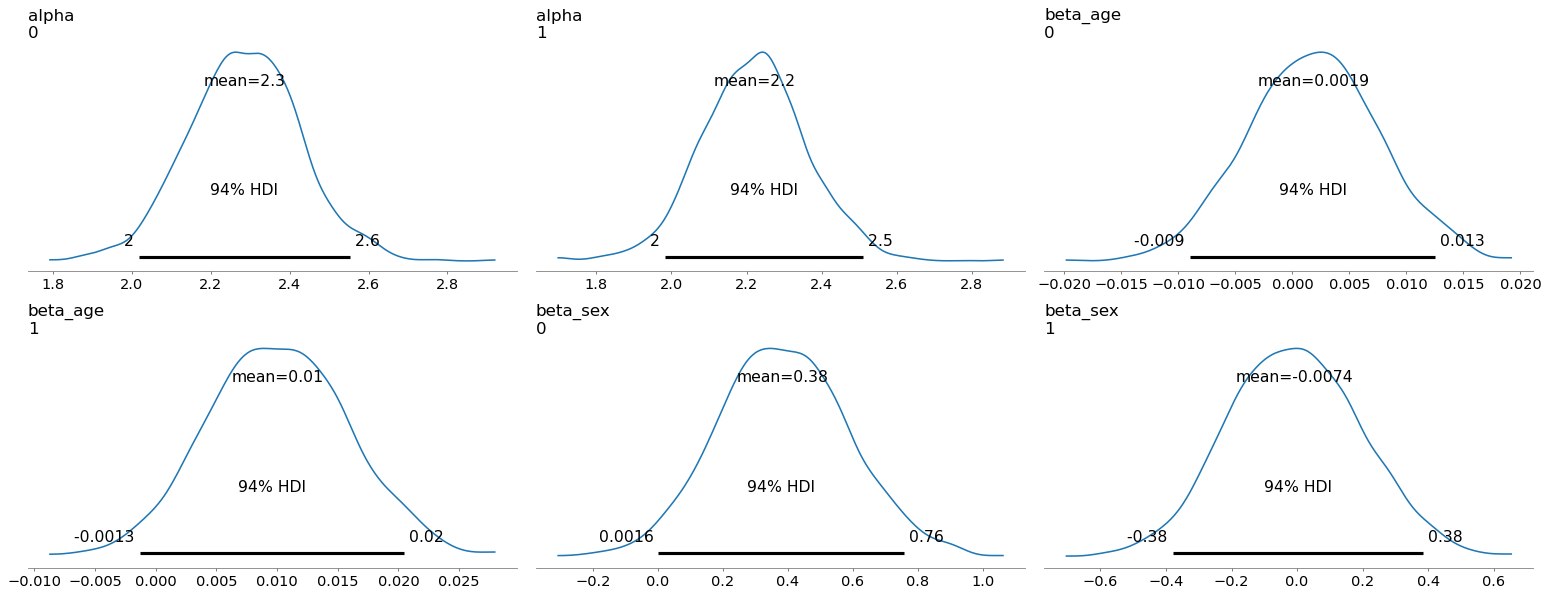

In [32]:
az.plot_posterior(idata2)
decorate()

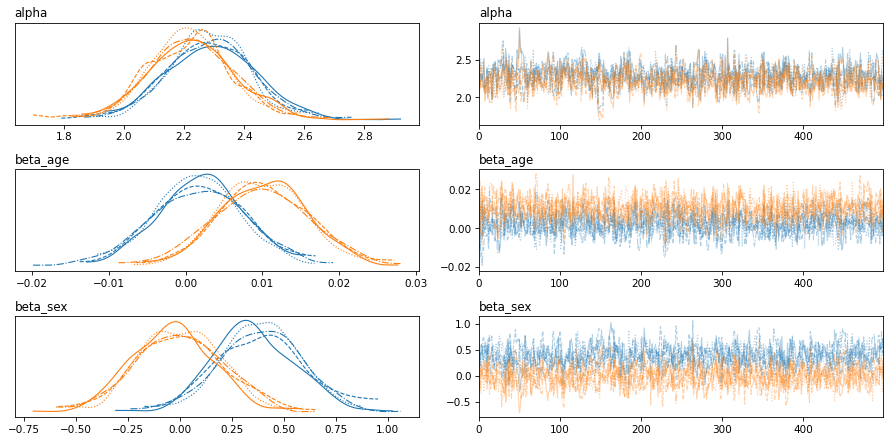

In [33]:
az.plot_trace(idata2)
decorate()

In [34]:
az.summary(idata2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],2.285,0.141,2.018,2.552,0.005,0.004,692.0,822.0,1.01
alpha[1],2.221,0.141,1.984,2.510,0.005,0.004,725.0,844.0,1.00
beta_age[0],0.002,0.006,-0.009,0.013,0.000,0.000,967.0,1117.0,1.01
beta_age[1],0.010,0.006,-0.001,0.020,0.000,0.000,984.0,954.0,1.00
beta_sex[0],0.384,0.202,0.002,0.758,0.008,0.005,611.0,1020.0,1.00
beta_sex[1],-0.007,0.204,-0.379,0.384,0.008,0.005,658.0,830.0,1.00


### Plotting the results

In [55]:
alpha = get_sample(idata2, "alpha").values
beta_age = get_sample(idata2, "beta_age").values
beta_sex = get_sample(idata2, "beta_sex").values
alpha.shape

(2, 2000)

<IPython.core.display.Javascript object>

In [57]:
def compute_predicted_probs(alpha, beta_age, beta_sex, age_centered, sex):
    """Compute predicted probabilities for a given sex (0=male, 1=female).

    alpha: array of shape (2, n_samples)
    beta_age: array of shape (2, n_samples)
    beta_sex: array of shape (2, n_samples)
    age_centered: array of centered ages
    sex: 0 for male, 1 for female

    returns: array of shape (n_samples, n_ages, 3) with predicted probabilities in percent
    """
    n_samples = alpha.shape[1]
    n_ages = len(age_centered)

    predicted_probs = np.zeros((n_samples, n_ages, 3))

    for i in range(n_samples):
        logit_other = np.zeros(n_ages)
        logit_biden = alpha[0, i] + beta_age[0, i] * age_centered + beta_sex[0, i] * sex
        logit_trump = alpha[1, i] + beta_age[1, i] * age_centered + beta_sex[1, i] * sex

        logits = np.stack([logit_other, logit_biden, logit_trump], axis=1)
        predicted_probs[i] = softmax(logits, axis=1) * 100

    return predicted_probs

<IPython.core.display.Javascript object>

In [58]:
predicted_probs_male = compute_predicted_probs(
    alpha, beta_age, beta_sex, age_centered, sex=0
)
predicted_probs_female = compute_predicted_probs(
    alpha, beta_age, beta_sex, age_centered, sex=1
)

<IPython.core.display.Javascript object>

In [59]:
def plot_predictions_by_sex(age_range, predicted_probs, ls="-"):
    """Plot predicted probabilities for one sex (male or female).

    age_range: array of ages to plot
    predicted_probs: array of shape (n_samples, n_ages, 3)
    ls: string for matplotlib line style
    """
    for i, name in vote_map.items():
        probs = predicted_probs[:, :, i]
        mean_prob = probs.mean(axis=0)
        hdi_low, hdi_high = np.percentile(probs, [5, 95], axis=0)

        plt.plot(
            age_range,
            mean_prob,
            color=colors[i],
            alpha=0.5,
            ls=ls,
        )
        plt.fill_between(
            age_range,
            hdi_low,
            hdi_high,
            color=colors[i],
            alpha=0.1,
            lw=0,
        )

<IPython.core.display.Javascript object>

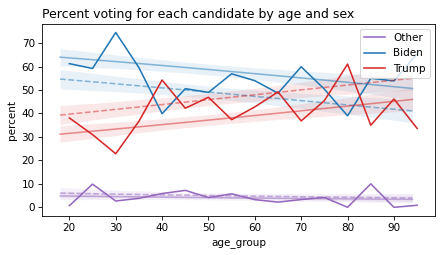

<IPython.core.display.Javascript object>

In [60]:
table.plot(color=colors)

plot_predictions_by_sex(age_range, predicted_probs_male, ls="--")
plot_predictions_by_sex(age_range, predicted_probs_female, ls="-")

decorate(ylabel="percent", title="Percent voting for each candidate by age and sex")